# Laptop Price Prediction using Machine Learning

**Goal:** Predict a laptop's price from its specifications (brand, RAM, CPU, GPU, storage, screen, etc.)

**Pipeline:** Data Collection -> Preprocessing -> EDA -> Encoding -> Train-Test Split -> Model Training -> Evaluation -> Save Best Model

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

%matplotlib inline

## 2. Reading the Dataset

In [2]:
data = pd.read_csv('../data/laptop_price.csv', encoding='windows-1252')
data.shape

(1303, 13)

## 3. Dropping Unnecessary Columns
`laptop_ID` is just a row identifier - it carries no predictive information.

In [3]:
data.drop(['laptop_ID'], axis=1, inplace=True)

## 4. Displaying Data for Inspection

In [4]:
data.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [5]:
data.tail()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
1298,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,638.0
1299,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,1499.0
1300,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,229.0
1301,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.0
1302,Asus,X553SA-XX031T (N3050/4GB/500GB/W10),Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,500GB HDD,Intel HD Graphics,Windows 10,2.2kg,369.0


## 5. Data Overview

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   str    
 1   Product           1303 non-null   str    
 2   TypeName          1303 non-null   str    
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   str    
 5   Cpu               1303 non-null   str    
 6   Ram               1303 non-null   str    
 7   Memory            1303 non-null   str    
 8   Gpu               1303 non-null   str    
 9   OpSys             1303 non-null   str    
 10  Weight            1303 non-null   str    
 11  Price_euros       1303 non-null   float64
dtypes: float64(2), str(10)
memory usage: 122.3 KB


## 6. Null Value Detection

In [7]:
data.isnull().sum()

Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

## 7. Exploratory Data Analysis

In [8]:
data['TypeName'].unique()

<StringArray>
[         'Ultrabook',           'Notebook',            'Netbook',
             'Gaming', '2 in 1 Convertible',        'Workstation']
Length: 6, dtype: str

In [9]:
a = data['TypeName'].value_counts()
a

TypeName
Notebook              727
Gaming                205
Ultrabook             196
2 in 1 Convertible    121
Workstation            29
Netbook                25
Name: count, dtype: int64

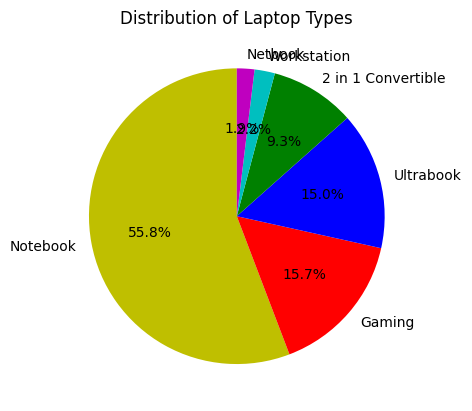

In [10]:
plt.figure()
plt.pie(a, labels=a.index, autopct='%1.1f%%', startangle=90,
        colors=['y','r','b','g','c','m'])
plt.title('Distribution of Laptop Types')
plt.show()

In [11]:
print(data['Product'].unique())
print(data['OpSys'].unique())
print(data['Gpu'].unique())

<StringArray>
[                              'MacBook Pro',
                               'Macbook Air',
                                    '250 G6',
                                  'Aspire 3',
                           'ZenBook UX430UN',
                                   'Swift 3',
                             'Inspiron 3567',
                               'MacBook 12"',
                         'IdeaPad 320-15IKB',
                                    'XPS 13',
 ...
                               'GE62 Apache',
                            'Yoga 500-14IBD',
                      'ZenBook UX305CA-UBM1',
                            'Aspire ES1-531',
                       'Pavilion 15-AW003nv',
                          'Stream 11-Y000na',
 'X556UJ-XO044T (i7-6500U/4GB/500GB/GeForce',
                            'Yoga 500-14ISK',
       '15-AC110nv (i7-6500U/6GB/1TB/Radeon',
       'X553SA-XX031T (N3050/4GB/500GB/W10)']
Length: 618, dtype: str
<StringArray>
[       'macOS',       

In [12]:
b = data['Product'].value_counts()
c = data['OpSys'].value_counts()
d = data['Gpu'].value_counts()
c

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

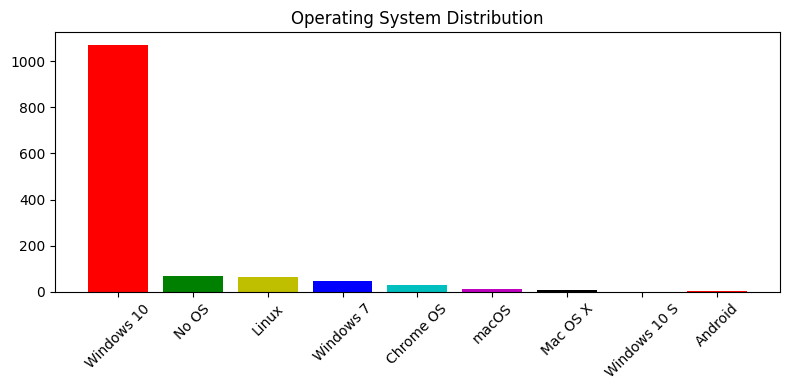

In [13]:
plt.figure(figsize=(8,4))
plt.bar(c.index, c, color=['r','g','y','b','c','m','k','w','r'])
plt.title('Operating System Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Label Encoding (Categorical -> Numeric)

Machine learning models need numbers, not text. We convert every categorical column into a numeric label. Each encoder is saved so the same mapping can be reused later when a user submits a new laptop's specs through the web app.

In [14]:
categorical_cols = ['TypeName', 'Company', 'Ram', 'Gpu', 'ScreenResolution',
                     'Cpu', 'Memory', 'Product', 'OpSys', 'Weight']

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    encoders[col] = le

data.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,300,4,13.3,23,65,8,4,58,8,38,1339.69
1,1,301,4,13.3,1,63,8,2,51,8,35,898.94
2,7,50,3,15.6,8,74,8,16,53,4,74,575.00
3,1,300,4,15.4,25,85,1,29,9,8,71,2537.45
4,1,300,4,13.3,23,67,8,16,59,8,38,1803.60


## 9. Train-Test Split

**Note on scaling:** an earlier version of this notebook applied `StandardScaler` to the target column (`Price_euros`) as well as `Inches`. That's a common beginner trap - scaling the target means the model's raw predictions come out in scaled units (roughly -3 to +3) instead of real currency, and you have to remember to `inverse_transform` every prediction back to euros. Tree-based models like Random Forest don't need feature scaling at all, and keeping `Price_euros` unscaled means predictions are directly usable. So this version skips scaling entirely.

In [15]:
X = data.drop('Price_euros', axis=1)
y = data['Price_euros']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((1042, 11), (261, 11))

## 10. Model 1 - Linear Regression (baseline)

We start with a simple linear model as a baseline, exactly as in the original exploration.

In [16]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

lr_r2 = r2_score(y_test, lr_preds)
lr_mae = mean_absolute_error(y_test, lr_preds)

print(f"Linear Regression -> R2: {lr_r2:.4f} | MAE: {lr_mae:.2f}")

Linear Regression -> R2: 0.3964 | MAE: 377.07


## 11. Model 2 - Random Forest Regression

Laptop pricing isn't linear (doubling RAM doesn't double the price, and brand/GPU tier interact with each other). Random Forest builds many decision trees and averages them, which captures these non-linear relationships much better than a single straight-line fit.

In [17]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=14, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, rf_preds)
rf_mae = mean_absolute_error(y_test, rf_preds)

print(f"Random Forest -> R2: {rf_r2:.4f} | MAE: {rf_mae:.2f}")

Random Forest -> R2: 0.8381 | MAE: 167.96


## 12. Model Comparison

In [18]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2 Score': [lr_r2, rf_r2],
    'MAE (EUR)': [lr_mae, rf_mae]
})
comparison

,Model,R2 Score,MAE (EUR)
0,Linear Regression,0.396372,377.073991
1,Random Forest,0.838082,167.963346


## 13. Best Model Selection & Saving

We select whichever model scored higher on R^2, then save the model, the label encoders, and the feature column order together - all three are needed by the Flask app to encode a new laptop's specs the exact same way and produce a prediction in real euros.

In [19]:
best_model = rf_model if rf_r2 >= lr_r2 else lr_model
best_name = "Random Forest Regression" if rf_r2 >= lr_r2 else "Linear Regression"
print("Best model:", best_name)

with open('../model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('../encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

with open('../feature_columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print("Model and encoders saved successfully.")

Best model: Random Forest Regression
Model and encoders saved successfully.


## 14. Quick Sanity Check - Predict on a Real Row

Before trusting the saved model, we predict on a row from the test set and compare it against the actual price - this is the same check used before connecting the model to the Flask app.

In [20]:
sample = X_test.iloc[[0]]
actual_price = y_test.iloc[0]
predicted_price = best_model.predict(sample)[0]

print(f"Actual price:    EUR {actual_price:.2f}")
print(f"Predicted price: EUR {predicted_price:.2f}")

Actual price:    EUR 1672.00
Predicted price: EUR 1366.88
